# Experimental Evaluation of Machine Learning Attacks on XOR Arbiter PUF

This notebook presents a structured experimental evaluation of machine learning attacks on XOR Arbiter Physical Unclonable Functions (PUFs).

The experiments conducted include:

1. CRP Scaling Study
2. XOR Order Complexity Study
3. Noise Robustness Study
4. Statistical Stability Analysis

All core PUF logic and attack models are imported from the `src/` module.


In [1]:
# ============================================================
# GLOBAL SEED (REPRODUCIBILITY)
# ============================================================

SEED = 42


## IMPORT LIBRARIES

In [2]:
# ============================================================
# IMPORTS
# ============================================================

import sys
sys.path.append("../")

import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split

from src.puf_models import XORPUF, generate_crps
from src.attack_models import logistic_attack, mlp_attack


In [3]:
# ============================================================
# CREATE RESULTS FOLDERS (if not already present)
# ============================================================

import os

os.makedirs("results/graphs", exist_ok=True)
os.makedirs("results/logs", exist_ok=True)


# EXPERIMENT 1 — CRP Scaling Study

## 1. CRP Scaling Study

This experiment evaluates how increasing the number of Challenge-Response Pairs (CRPs) affects the attack accuracy of:

- Logistic Regression (Linear Model)
- Multi-Layer Perceptron (Non-linear Model)

The XOR order is fixed.


In [4]:
# ============================================================
# CRP SCALING EXPERIMENT
# ============================================================

num_stages = 32
num_xor    = 3
crp_list   = [1000, 5000, 10000, 20000, 50000]

linear_acc = []
mlp_acc    = []

for num_samples in crp_list:

    # Build a fresh PUF for each CRP count (same seed → same device weights)
    puf = XORPUF(n_stages=num_stages, k=num_xor, noise=0.0, seed=SEED)

    # Generate dataset
    X, y = generate_crps(puf, num_samples=num_samples, seed=SEED)

    # Split dataset
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=SEED
    )

    # Run attacks
    linear_accuracy, _ = logistic_attack(X_train, y_train, X_test, y_test, seed=SEED)
    mlp_accuracy,    _ = mlp_attack(X_train, y_train, X_test, y_test, seed=SEED)

    linear_acc.append(linear_accuracy)
    mlp_acc.append(mlp_accuracy)


## CRP Scaling Study Plot

This plot shows how attack accuracy varies as the number of
Challenge-Response Pairs (CRPs) increases.

Comparison:
- Logistic Regression (Linear Model)
- MLP (Non-linear Model)


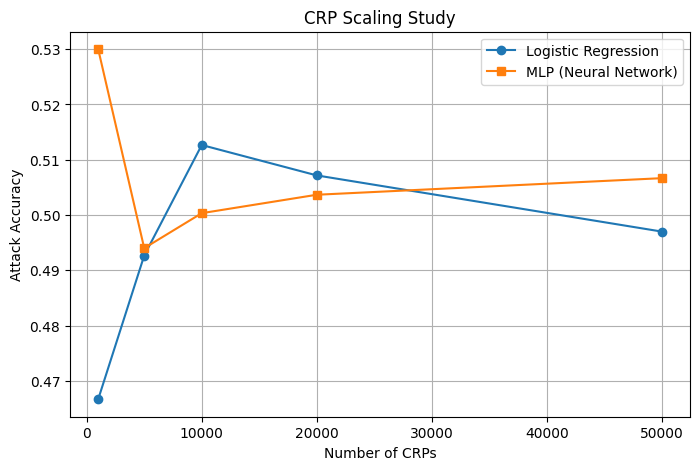

In [5]:
# ============================================================
# PLOT: CRP SCALING STUDY
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(crp_list, linear_acc, marker='o', label="Logistic Regression")
plt.plot(crp_list, mlp_acc,    marker='s', label="MLP (Neural Network)")

plt.xlabel("Number of CRPs")
plt.ylabel("Attack Accuracy")
plt.title("CRP Scaling Study")
plt.legend()
plt.grid(True)

plt.savefig("results/graphs/crp_scaling.png", dpi=300)
plt.show()


In [6]:
# ============================================================
# SAVE CRP RESULTS TO CSV
# ============================================================

import pandas as pd

crp_df = pd.DataFrame({
    "CRP_Count"         : crp_list,
    "Logistic_Accuracy" : linear_acc,
    "MLP_Accuracy"      : mlp_acc
})

crp_df.to_csv("results/logs/crp_scaling_results.csv", index=False)


# EXPERIMENT 2 — XOR ORDER STUDY

In [7]:
# ============================================================
# XOR ORDER COMPLEXITY EXPERIMENT
# ============================================================

num_samples  = 30000
num_stages   = 32
xor_list     = [1, 2, 3, 4, 5]

linear_acc_xor = []
mlp_acc_xor    = []

for num_xor in xor_list:

    # Build PUF for this XOR level
    puf = XORPUF(n_stages=num_stages, k=num_xor, noise=0.0, seed=SEED)

    # Generate dataset
    X, y = generate_crps(puf, num_samples=num_samples, seed=SEED)

    # Split dataset
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=SEED
    )

    # Run attacks
    linear_accuracy, _ = logistic_attack(X_train, y_train, X_test, y_test, seed=SEED)
    mlp_accuracy,    _ = mlp_attack(X_train, y_train, X_test, y_test, seed=SEED)

    linear_acc_xor.append(linear_accuracy)
    mlp_acc_xor.append(mlp_accuracy)


## XOR Order Complexity Plot

This plot evaluates how increasing XOR order impacts
modeling attack accuracy.


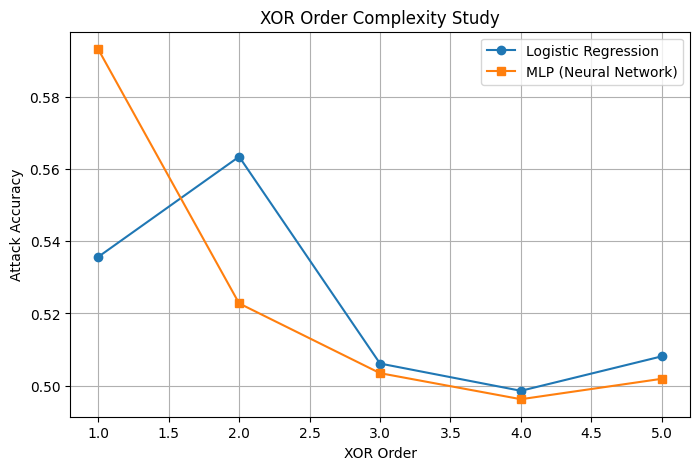

In [8]:
# ============================================================
# PLOT: XOR ORDER COMPLEXITY
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(xor_list, linear_acc_xor, marker='o', label="Logistic Regression")
plt.plot(xor_list, mlp_acc_xor,    marker='s', label="MLP (Neural Network)")

plt.xlabel("XOR Order")
plt.ylabel("Attack Accuracy")
plt.title("XOR Order Complexity Study")
plt.legend()
plt.grid(True)

plt.savefig("results/graphs/xor_complexity.png", dpi=300)
plt.show()


In [9]:
# ============================================================
# SAVE XOR COMPLEXITY RESULTS
# ============================================================

xor_df = pd.DataFrame({
    "XOR_Order"         : xor_list,
    "Logistic_Accuracy" : linear_acc_xor,
    "MLP_Accuracy"      : mlp_acc_xor
})

xor_df.to_csv("results/logs/xor_complexity_results.csv", index=False)


# EXPERIMENT 3 — NOISE ROBUSTNESS

In [10]:
# ============================================================
# NOISE ROBUSTNESS EXPERIMENT
# ============================================================

num_samples  = 30000
num_stages   = 32
num_xor      = 3
sigma_list   = [0, 0.05, 0.1, 0.2, 0.3, 0.5]

mlp_noise_acc = []

for sigma in sigma_list:

    # Build PUF with noise
    puf = XORPUF(n_stages=num_stages, k=num_xor, noise=sigma, seed=SEED)

    # Generate dataset
    X, y = generate_crps(puf, num_samples=num_samples, seed=SEED)

    # Split dataset
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=SEED
    )

    # Run MLP attack
    accuracy, _ = mlp_attack(X_train, y_train, X_test, y_test, seed=SEED)

    mlp_noise_acc.append(accuracy)


## Noise Robustness Plot

This plot shows how environmental noise (sigma)
affects neural network modeling accuracy.


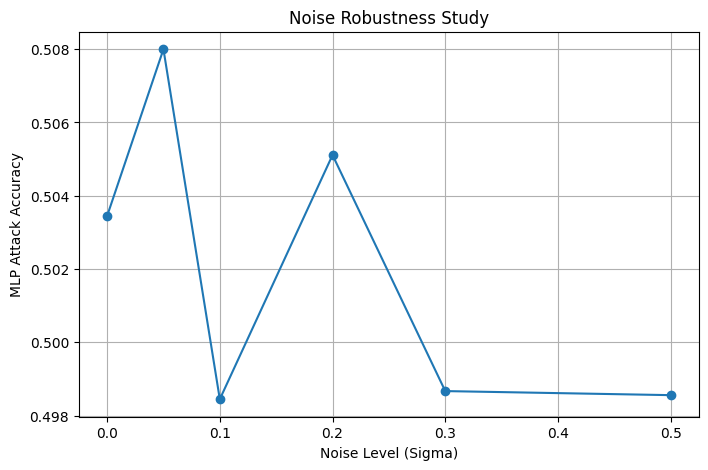

In [11]:
# ============================================================
# PLOT: NOISE ROBUSTNESS
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(sigma_list, mlp_noise_acc, marker='o')

plt.xlabel("Noise Level (Sigma)")
plt.ylabel("MLP Attack Accuracy")
plt.title("Noise Robustness Study")
plt.grid(True)

plt.savefig("results/graphs/noise_robustness.png", dpi=300)
plt.show()


In [12]:
# ============================================================
# SAVE NOISE ROBUSTNESS RESULTS
# ============================================================

noise_df = pd.DataFrame({
    "Sigma"        : sigma_list,
    "MLP_Accuracy" : mlp_noise_acc
})

noise_df.to_csv("results/logs/noise_results.csv", index=False)


# EXPERIMENT 4 — STATISTICAL NOISE STUDY

In [13]:
# ============================================================
# STATISTICAL NOISE ANALYSIS (MEAN ± STD)
# Reproducible multi-trial evaluation
# ============================================================

num_trials   = 5
mean_results = []
std_results  = []

for sigma in sigma_list:

    trial_accuracies = []

    for trial in range(num_trials):

        # Deterministic but distinct seed per trial
        trial_seed = SEED + trial

        # Build PUF with noise
        puf = XORPUF(n_stages=num_stages, k=num_xor, noise=sigma, seed=trial_seed)

        # Generate dataset
        X, y = generate_crps(puf, num_samples=num_samples, seed=trial_seed)

        # Split dataset
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.3, random_state=trial_seed
        )

        # Run MLP attack
        accuracy, _ = mlp_attack(X_train, y_train, X_test, y_test, seed=trial_seed)

        trial_accuracies.append(accuracy)

    mean_results.append(np.mean(trial_accuracies))
    std_results.append(np.std(trial_accuracies))


## Statistical Noise Analysis (Mean ± Std)

This plot shows the mean modeling accuracy under noise
with standard deviation error bars.


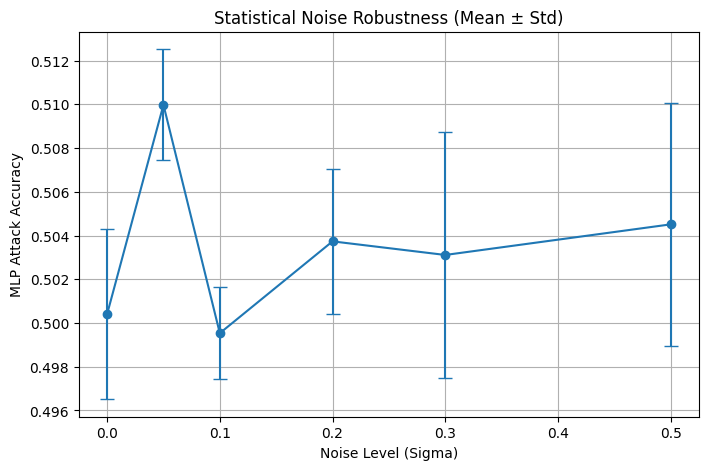

In [14]:
# ============================================================
# PLOT: STATISTICAL NOISE ANALYSIS
# ============================================================

plt.figure(figsize=(8, 5))

plt.errorbar(sigma_list, mean_results, yerr=std_results,
             marker='o', capsize=5)

plt.xlabel("Noise Level (Sigma)")
plt.ylabel("MLP Attack Accuracy")
plt.title("Statistical Noise Robustness (Mean ± Std)")
plt.grid(True)

plt.savefig("results/graphs/statistical_noise.png", dpi=300)
plt.show()


In [15]:
# ============================================================
# SAVE STATISTICAL NOISE RESULTS
# ============================================================

stat_df = pd.DataFrame({
    "Sigma"         : sigma_list,
    "Mean_Accuracy" : mean_results,
    "Std_Accuracy"  : std_results
})

stat_df.to_csv("results/logs/statistical_noise_results.csv", index=False)
